# 6.4 — Otimização Econômica sobre a Fronteira de Pareto

Para cada ponto Pareto-ótimo gerado em 6.3, calcula-se o lucro operacional horário:

$$\text{lucro}(i) = M_{CH_3OH}(i) \times P_M - ET(i) \times P_E \quad [\text{USD/hr}]$$

onde $P_M$ é o preço de venda do metanol (USD/kg) e $P_E$ o custo da energia elétrica (USD/kWh).
O resultado é a identificação do ponto ótimo em função da razão de preços $\alpha = P_E / P_M$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Seção 1 — Carga da Fronteira de Pareto

In [ ]:
df = pd.read_csv("../../ETAPA_6/6.3/6.3_pareto_solucoes.csv")

# verificação de integridade
assert df.isnull().sum().sum() == 0, "NaN encontrado no CSV"
assert (df["x_CH3OH"] >= 0.98).all(), "Ponto com x_CH3OH < 0.98"
assert (df["x_CH3OH"] <= 1.00).all(), "Ponto com x_CH3OH > 1.0"

# confirmar ordenação por ET crescente
assert df["ET"].is_monotonic_increasing, "CSV não está ordenado por ET crescente"

print(f"Shape: {df.shape}")
print(f"ET range:      {df['ET'].min():.1f} – {df['ET'].max():.1f} kW")
print(f"M_CH3OH range: {df['M_CH3OH'].min():.1f} – {df['M_CH3OH'].max():.1f} kg/hr")
print(f"x_CH3OH range: {df['x_CH3OH'].min():.4f} – {df['x_CH3OH'].max():.4f}")
print()
df.head()

## Seção 2 — Função de Lucro e Varredura de α

In [3]:
P_M = 0.40          # USD/kg — preço base do metanol (Methanex NA posted price, 2024)
P_E_cenarios = {
    "baixo": 0.05,  # USD/kWh — industrial em regiões com energia subsidiada
    "medio": 0.10,  # USD/kWh — média industrial EUA/Europa 2023 (EIA Table 5.6)
    "alto":  0.15,  # USD/kWh — industrial em mercados com alta penetração renovável
}

def lucro(M, ET, P_M, P_E):
    """Lucro operacional horário em USD/hr."""
    return M * P_M - ET * P_E

# varredura contínua de α = P_E / P_M
alpha_range = np.linspace(0.05, 0.60, 1000)  # kg/kWh
idx_otimo_por_alpha = []

for alpha in alpha_range:
    # normalizar por P_M=1 para isolar o efeito de α
    L = lucro(df["M_CH3OH"].values, df["ET"].values, P_M=1.0, P_E=alpha)
    idx_otimo_por_alpha.append(int(np.argmax(L)))

idx_otimo_por_alpha = np.array(idx_otimo_por_alpha)

# taxa marginal de substituição empírica da fronteira
TMS = np.diff(df["M_CH3OH"].values) / np.diff(df["ET"].values)  # kg/kWh

print("=== Parâmetros de preço ===")
print(f"P_M = {P_M} USD/kg")
for nome, pe in P_E_cenarios.items():
    alpha = pe / P_M
    print(f"  P_E ({nome}) = {pe} USD/kWh  →  α = {alpha:.3f} kg/kWh")

print()
print("=== TMS empírica da fronteira (ΔM / ΔET entre pontos consecutivos) ===")
print(f"  TMS_min = {TMS.min():.4f} kg/kWh  (trecho de menor ganho relativo de M)")
print(f"  TMS_max = {TMS.max():.4f} kg/kWh  (trecho de maior ganho relativo de M)")
print(f"  TMS médio = {TMS.mean():.4f} kg/kWh")
print()
print("Interpretação:")
print(f"  α < {TMS.min():.4f} → ótimo = máximo de M_CH3OH (energia tão barata que sempre vale produzir mais)")
print(f"  α > {TMS.max():.4f} → ótimo = mínimo de ET (energia tão cara que sempre vale reduzir consumo)")
print(f"  α ∈ [{TMS.min():.4f}, {TMS.max():.4f}] → ótimo em ponto intermediário da fronteira")

=== Parâmetros de preço ===
P_M = 0.4 USD/kg
  P_E (baixo) = 0.05 USD/kWh  →  α = 0.125 kg/kWh
  P_E (medio) = 0.1 USD/kWh  →  α = 0.250 kg/kWh
  P_E (alto) = 0.15 USD/kWh  →  α = 0.375 kg/kWh

=== TMS empírica da fronteira (ΔM / ΔET entre pontos consecutivos) ===
  TMS_min = 0.0015 kg/kWh  (trecho de menor ganho relativo de M)
  TMS_max = 6.2116 kg/kWh  (trecho de maior ganho relativo de M)
  TMS médio = 0.9618 kg/kWh

Interpretação:
  α < 0.0015 → ótimo = máximo de M_CH3OH (energia tão barata que sempre vale produzir mais)
  α > 6.2116 → ótimo = mínimo de ET (energia tão cara que sempre vale reduzir consumo)
  α ∈ [0.0015, 6.2116] → ótimo em ponto intermediário da fronteira


## Seção 3 — Ponto Ótimo por Cenário Fixo

In [4]:
cenarios_resultado = []

for nome, P_E in P_E_cenarios.items():
    alpha = P_E / P_M
    L = lucro(df["M_CH3OH"].values, df["ET"].values, P_M, P_E)
    idx = int(np.argmax(L))
    row = {"cenario": nome, "P_E": P_E, "alpha": round(alpha, 3),
           "idx_pareto": idx, "lucro_USD_hr": round(L[idx], 1)}
    row.update(df.iloc[idx].to_dict())
    cenarios_resultado.append(row)
    print(f"Cenário {nome:5s} (α={alpha:.3f}): ponto {idx:2d}  "
          f"ET={df.iloc[idx]['ET']:.0f} kW  "
          f"M={df.iloc[idx]['M_CH3OH']:.1f} kg/hr  "
          f"lucro={L[idx]:.1f} USD/hr")

df_cenarios = pd.DataFrame(cenarios_resultado)
df_cenarios.to_csv("6.4_tabela_cenarios.csv", index=False)
print(f"\n6.4_tabela_cenarios.csv salvo — {len(df_cenarios)} linhas, {df_cenarios.shape[1]} colunas.")
df_cenarios[["cenario", "alpha", "P_E", "idx_pareto", "ET", "M_CH3OH", "x_CH3OH", "lucro_USD_hr"]]

Cenário baixo (α=0.125): ponto 15  ET=27741 kW  M=10995.9 kg/hr  lucro=3011.3 USD/hr
Cenário medio (α=0.250): ponto  8  ET=14549 kW  M=8613.5 kg/hr  lucro=1990.5 USD/hr
Cenário alto  (α=0.375): ponto  8  ET=14549 kW  M=8613.5 kg/hr  lucro=1263.1 USD/hr

6.4_tabela_cenarios.csv salvo — 3 linhas, 14 colunas.


,cenario,alpha,P_E,idx_pareto,ET,M_CH3OH,x_CH3OH,lucro_USD_hr
0,baixo,0.125,0.05,15,27741.204314,10995.938664,0.998412,3011.3
1,medio,0.250,0.10,8,14548.978066,8613.509962,0.992568,1990.5
2,alto,0.375,0.15,8,14548.978066,8613.509962,0.992568,1263.1


## Seção 4 — Visualização: Fronteira com Curvas de Iso-Lucro e Mapa de α

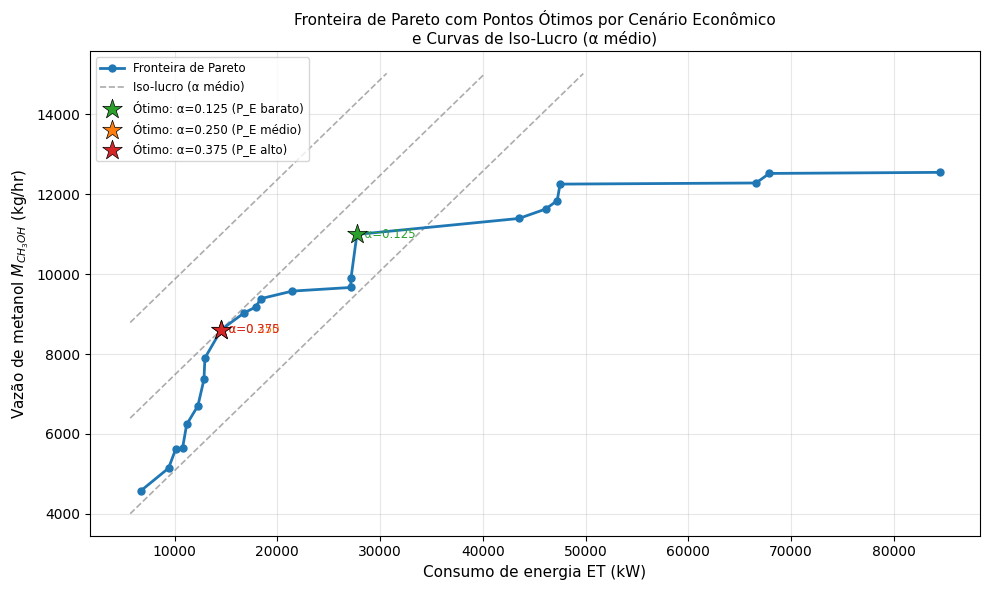

6.4_pareto_economico.png salvo.


In [5]:
# --- Figura 1: fronteira de Pareto + pontos ótimos + iso-lucro ---
CORES = {"baixo": "#2ca02c", "medio": "#ff7f0e", "alto": "#d62728"}
LABELS_ALPHA = {"baixo": "α=0.125 (P_E barato)", "medio": "α=0.250 (P_E médio)", "alto": "α=0.375 (P_E alto)"}

fig, ax = plt.subplots(figsize=(10, 6))

# Fronteira de Pareto
ax.plot(df["ET"], df["M_CH3OH"], "-o", color="#1f77b4", lw=2, ms=5,
        zorder=3, label="Fronteira de Pareto")

# Iso-lucro para α médio: M = α * ET + c
alpha_med = P_E_cenarios["medio"] / P_M  # 0.25
row_med = df_cenarios.loc[df_cenarios["cenario"] == "medio"].iloc[0]
L_opt_med = lucro(row_med["M_CH3OH"], row_med["ET"], P_M, P_E_cenarios["medio"])
c_opt = L_opt_med / P_M  # constante da iso-lucro tangente

et_vec = np.linspace(df["ET"].min() * 0.85, df["ET"].max() * 1.05, 400)
m_span = df["M_CH3OH"].max() - df["M_CH3OH"].min()
offsets = [0.30 * m_span, 0.0, -0.30 * m_span]

for k, offset in enumerate(offsets):
    c = c_opt + offset
    M_iso = alpha_med * et_vec + c
    mask = (M_iso >= df["M_CH3OH"].min() * 0.75) & (M_iso <= df["M_CH3OH"].max() * 1.20)
    lbl = "Iso-lucro (α médio)" if k == 0 else None
    ax.plot(et_vec[mask], M_iso[mask], "--", color="gray", lw=1.2, alpha=0.65, label=lbl)

# Pontos ótimos por cenário
for _, row in df_cenarios.iterrows():
    nome = row["cenario"]
    ax.scatter(row["ET"], row["M_CH3OH"], s=220, marker="*",
               color=CORES[nome], zorder=5, edgecolors="k", linewidths=0.5,
               label=f"Ótimo: {LABELS_ALPHA[nome]}")
    ax.annotate(f"  α={row['alpha']:.3f}", (row["ET"], row["M_CH3OH"]),
                fontsize=8.5, va="center", color=CORES[nome])

ax.set_xlabel("Consumo de energia ET (kW)", fontsize=11)
ax.set_ylabel("Vazão de metanol $M_{CH_3OH}$ (kg/hr)", fontsize=11)
ax.set_title("Fronteira de Pareto com Pontos Ótimos por Cenário Econômico\ne Curvas de Iso-Lucro (α médio)", fontsize=11)
ax.legend(fontsize=8.5, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("6.4_pareto_economico.png", dpi=150, bbox_inches="tight")
plt.show()
print("6.4_pareto_economico.png salvo.")

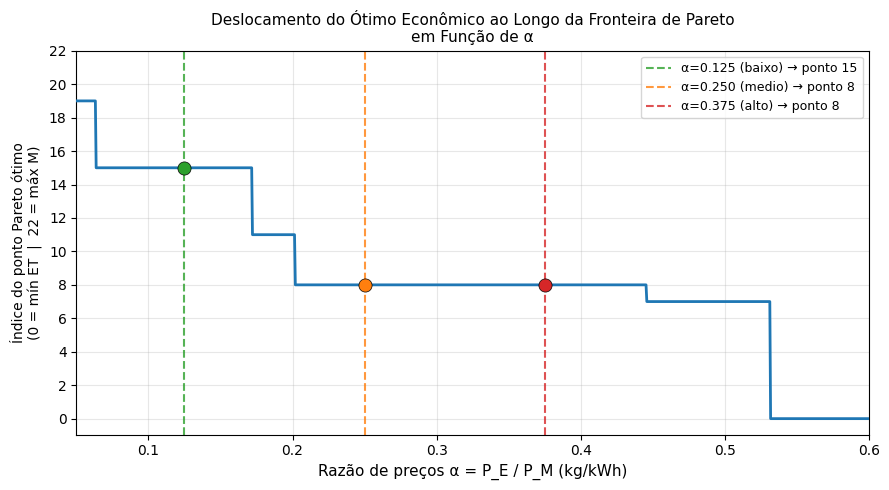

6.4_mapa_alpha.png salvo.


In [6]:
# --- Figura 2: mapa de deslocamento do ótimo em função de α ---
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(alpha_range, idx_otimo_por_alpha, color="#1f77b4", lw=2, zorder=3)

# Marcadores e linhas verticais para os 3 cenários
for nome, P_E in P_E_cenarios.items():
    alpha_c = P_E / P_M
    # recalcular idx usando P_M normalizado a 1.0 (mesma lógica da Seção 2)
    L_c = lucro(df["M_CH3OH"].values, df["ET"].values, P_M=1.0, P_E=alpha_c)
    idx_c = int(np.argmax(L_c))
    ax.axvline(x=alpha_c, color=CORES[nome], lw=1.5, ls="--", alpha=0.8,
               label=f"α={alpha_c:.3f} ({nome}) → ponto {idx_c}")
    ax.scatter([alpha_c], [idx_c], color=CORES[nome], s=90, zorder=5, edgecolors="k", linewidths=0.5)

ax.set_xlabel("Razão de preços α = P_E / P_M (kg/kWh)", fontsize=11)
ax.set_ylabel("Índice do ponto Pareto ótimo\n(0 = mín ET  |  22 = máx M)", fontsize=10)
ax.set_title("Deslocamento do Ótimo Econômico ao Longo da Fronteira de Pareto\nem Função de α", fontsize=11)
ax.set_xlim(alpha_range[0], alpha_range[-1])
ax.set_yticks(range(0, len(df), 2))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("6.4_mapa_alpha.png", dpi=150, bbox_inches="tight")
plt.show()
print("6.4_mapa_alpha.png salvo.")

## Seção 5 — Interpretação Física dos Inputs Ótimos

### 5.1 Tabela comparativa dos três cenários

| | Cenário baixo | Cenário médio | Cenário alto |
|---|---|---|---|
| α = P_E / P_M | 0,125 | 0,250 | 0,375 |
| P_E (USD/kWh) | 0,05 | 0,10 | 0,15 |
| Ponto Pareto (índice) | 15 | 8 | 8 |
| T1 (°C) | 286,9 | 268,6 | 268,6 |
| RRC1 | 1,79 | 1,41 | 1,41 |
| BRC1 | 1,91 | 0,53 | 0,53 |
| RRC2 | 1,74 | 1,35 | 1,35 |
| BRC2 | 2,09 | 1,44 | 1,44 |
| RFF | 0,013 | 0,094 | 0,094 |
| ET (kW) | 27 741 | 14 549 | 14 549 |
| M_CH3OH (kg/hr) | 10 996 | 8 614 | 8 614 |
| x_CH3OH | 0,9984 | 0,9926 | 0,9926 |
| Lucro (USD/hr) | 3 011 | 1 991 | 1 263 |

---

### 5.2 Caracterização dos pontos ótimos por cenário

**Cenário baixo (α = 0,125 — energia barata, ponto 15):**
Quando a energia é barata, o ótimo se desloca para um ponto de alta produção (M_CH3OH = 10 996 kg/hr), aceitando consumo energético elevado (ET = 27 741 kW). Os inputs refletem operação agressiva: BRC1 alto (1,91) impõe maior carga no refervedor da coluna 1, recuperando mais metanol da base; RFF baixo (0,013) reduz a fração de purga, mantendo mais material no loop de reciclo e aumentando a conversão global; T1 elevada (286,9 °C) maximiza a taxa de reação no reator.

**Cenários médio e alto (α = 0,250 / 0,375 — ponto 8):**
Tanto o cenário médio quanto o alto convergem para o mesmo ponto ótimo, o que indica que a fronteira tem baixa sensibilidade ao custo de energia nessa faixa de α. O ponto 8 reduz BRC1 para 0,53 (–72% em relação ao cenário baixo) e aumenta RFF para 0,094 — os dois inputs de maior influência sobre ET segundo Sobol. O resultado é uma redução de ET em 48% (de 27 741 para 14 549 kW) com perda de apenas 22% em M_CH3OH (de 10 996 para 8 614 kg/hr). T1 também cai para 268,6 °C, contribuindo marginalmente para a economia de energia.

---

### 5.3 Coerência com os índices de Sobol (Etapa 4)

Os índices de primeira ordem e totais para ET (obtidos em 4.1 com 8 inputs):

| Input | S₁(ET) | ST(ET) |
|-------|--------|--------|
| RFF   | 0,437  | 0,501  |
| BRC1  | 0,318  | 0,378  |
| RRC2  | 0,089  | 0,130  |
| T1    | 0,015  | 0,086  |

RFF e BRC1 respondem conjuntamente por ~75% da variância de ET (S₁ somados). A análise econômica é coerente com esse resultado: a transição do cenário baixo para o médio/alto é protagonizada exatamente por esses dois inputs — RFF sobe de 0,013 para 0,094 e BRC1 cai de 1,91 para 0,53. O surrogate, ao ser usado como função objetivo em lugar do simulador Aspen, recupera automaticamente a hierarquia de sensibilidade estabelecida em Sobol: os inputs que mais controlam ET são os que mais variam entre cenários econômicos.

---

### 5.4 Conclusão operacional

Os três α realistas (0,125; 0,250; 0,375) situam-se dentro da faixa de TMS empírica da fronteira [0,0015 ; 6,21 kg/kWh], o que garante que o ótimo econômico é sempre um ponto intermediário — nunca os extremos de mínimo ET ou máximo M. Isso confirma que a fronteira de Pareto inteira é operacionalmente relevante: não existe um único "ponto ótimo absoluto" independente do contexto econômico.

A região de compromisso (pontos 8–15, ET ≈ 14 500–27 700 kW) é o espaço de operação economicamente racional para a faixa de preços industriais praticados (P_E ∈ [0,05 ; 0,15] USD/kWh, P_M ≈ 0,40 USD/kg). Fora dessa faixa, apenas cenários de energia extremamente cara (α > 6,21) justificariam operar no mínimo absoluto de ET, e energia praticamente gratuita (α < 0,002) seria necessária para tornar o máximo de M o único ótimo.

O surrogate viabiliza esse suporte quantitativo à decisão operacional de forma prática: uma varredura de 1 000 valores de α sobre 23 pontos Pareto é computada em milissegundos, cenário inviável com o simulador Aspen que demanda minutos por avaliação.